In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import cross_val_score
from src.data_utils import load_california_housing

import sys
sys.path.append('..')

In [9]:
X, y = load_california_housing()
X = X[:, :2]
np.random.seed(42)
indices = np.random.permutation(len(X))[:3000]
X, y = X[indices], y[indices]

def create_learning_curve(X, y, degree, alpha = None):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    scaler = StandardScaler()
    X_poly = scaler.fit_transform(X_poly)
    
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_scores_mean = []
    train_scores_std = []
    val_scores_mean = []
    val_scores_std = []
    
    for train_size in train_sizes:
        n_samples = int(train_size * len(X_poly))
        X_subset = X_poly[:n_samples]
        y_subset = y[:n_samples]
        if alpha is not None:
            model = Ridge(alpha=alpha)
        else:
            model = LinearRegression()
        val_scores = cross_val_score(model, X_subset, y_subset, cv=5, scoring='r2')
        
        train_scores = []
        for train_idx, val_idx in [(np.arange(len(X_subset)//5*i, len(X_subset)//5*(i+1)), 
                                     np.concatenate([np.arange(len(X_subset)//5*j, len(X_subset)//5*(j+1)) 
                                                    for j in range(5) if j != i])) 
                                   for i in range(5)]:
            model.fit(X_subset[train_idx], y_subset[train_idx])
            train_scores.append(model.score(X_subset[train_idx], y_subset[train_idx]))
        
        train_scores_mean.append(np.mean(train_scores))
        train_scores_std.append(np.std(train_scores))
        val_scores_mean.append(np.mean(val_scores))
        val_scores_std.append(np.std(val_scores))
    
    return train_sizes, train_scores_mean, train_scores_std, val_scores_mean, val_scores_std

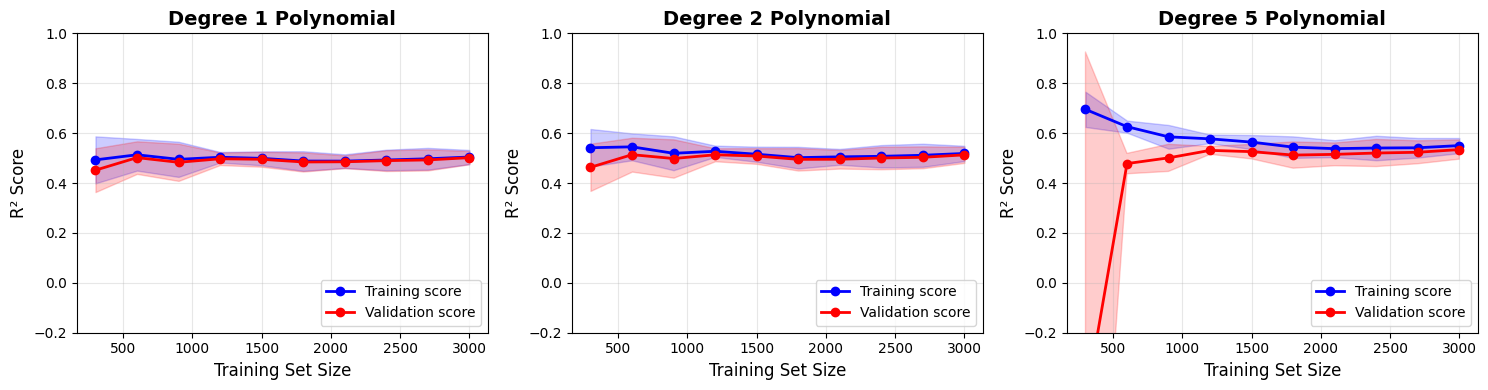

In [10]:
degrees = [1, 2, 5]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
curves_data = {}
for idx, degree in enumerate(degrees):
    train_sizes, train_mean, train_std, val_mean, val_std = create_learning_curve(X, y, degree)
    curves_data[degree] = (train_sizes, train_mean, train_std, val_mean, val_std)
    sample_sizes = (train_sizes * len(X)).astype(int)
    axes[idx].plot(sample_sizes, train_mean, 'o-', color='blue', linewidth=2, 
                   markersize=6, label='Training score')
    axes[idx].fill_between(sample_sizes, 
                           np.array(train_mean) - np.array(train_std),
                           np.array(train_mean) + np.array(train_std),
                           alpha=0.2, color='blue')
    
    axes[idx].plot(sample_sizes, val_mean, 'o-', color='red', linewidth=2,
                   markersize=6, label='Validation score')
    axes[idx].fill_between(sample_sizes,
                           np.array(val_mean) - np.array(val_std),
                           np.array(val_mean) + np.array(val_std),
                           alpha=0.2, color='red')
    
    axes[idx].set_xlabel('Training Set Size', fontsize=12)
    axes[idx].set_ylabel('R² Score', fontsize=12)
    axes[idx].set_title(f'Degree {degree} Polynomial', fontsize=14, fontweight='bold')
    axes[idx].set_ylim(-0.2, 1.0)
    axes[idx].legend(loc='lower right')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

α =    0.001: CV R² = 0.5341
α =    0.010: CV R² = 0.5341
α =    0.100: CV R² = 0.5342
α =    1.000: CV R² = 0.5344
α =   10.000: CV R² = 0.5340
α =  100.000: CV R² = 0.5292

Best α = 1.0 with CV R² = 0.5344


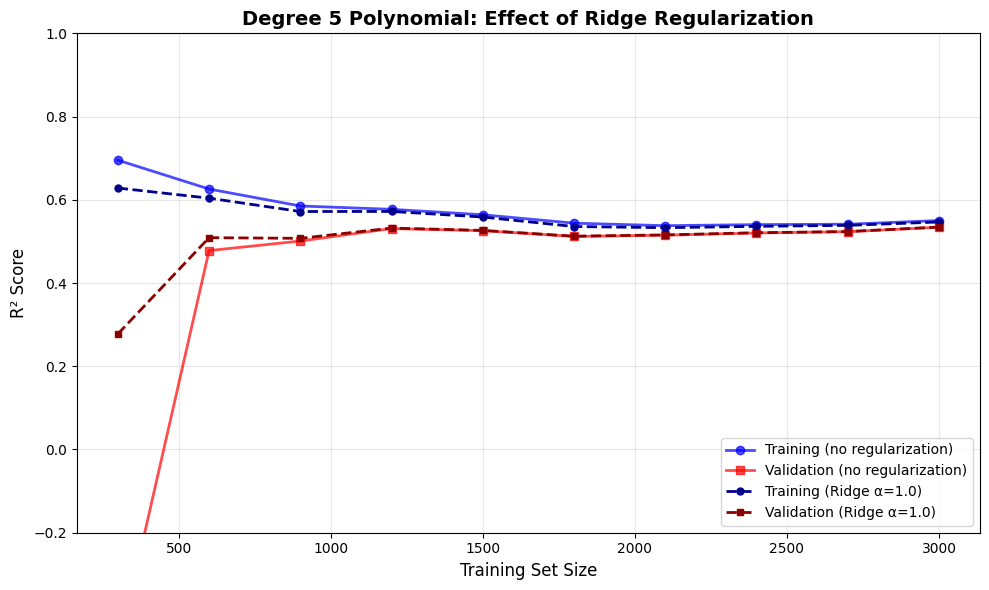

In [12]:
poly = PolynomialFeatures(degree=5, include_bias=False)
X_poly = poly.fit_transform(X)
scaler = StandardScaler()
X_poly = scaler.fit_transform(X_poly)

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_score = -np.inf

for alpha in alphas:
    model = Ridge(alpha=alpha)
    scores = cross_val_score(model, X_poly, y, cv=5, scoring='r2')
    mean_score = scores.mean()
    print(f"α = {alpha:8.3f}: CV R² = {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_alpha = alpha

print(f"\nBest α = {best_alpha} with CV R² = {best_score:.4f}")

train_sizes_ridge, train_mean_ridge, train_std_ridge, val_mean_ridge, val_std_ridge = create_learning_curve(X, y, degree=5, alpha=best_alpha)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
train_sizes_no_reg, train_mean_no_reg, train_std_no_reg, val_mean_no_reg, val_std_no_reg = curves_data[5]
sample_sizes = (train_sizes_no_reg * len(X)).astype(int)
sample_sizes_ridge = (train_sizes_ridge * len(X)).astype(int)

ax.plot(sample_sizes, train_mean_no_reg, 'o-', color='blue', linewidth=2, 
        label='Training (no regularization)', alpha=0.7)
ax.plot(sample_sizes, val_mean_no_reg, 's-', color='red', linewidth=2,
        label='Validation (no regularization)', alpha=0.7)

ax.plot(sample_sizes_ridge, train_mean_ridge, 'o--', color='darkblue', linewidth=2,
        label=f'Training (Ridge α={best_alpha})', markersize=5)
ax.plot(sample_sizes_ridge, val_mean_ridge, 's--', color='darkred', linewidth=2,
        label=f'Validation (Ridge α={best_alpha})', markersize=5)

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Degree 5 Polynomial: Effect of Ridge Regularization', fontsize=14, fontweight='bold')
ax.set_ylim(-0.2, 1.0)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1. - Highest bias: Degree 1
     Lowest scores and small gap between training and validation scores
   - Highest variance: Degree 5
     Larger gap between the scores (especially for small training set) 

2. Reduces the gap between the validation and training scores as we get less overfitting

3. For degree 1 the converges is very fast (around 600 samples), for degree 2 it converges around 1500 samples in training set and for degree 5 they seem to converge at around 2700 samples

4. We can evaluate total features as $\frac{(k+d)!}{d!k!}$ where d is polynomial degree and k is number of initial features so for larger numer of features it grows quickly

5. More original features capture more information about the problem however higher degree of polynomial can model non-linear relationship